# Compare Sampling Methods

Load one or two JSON result files from `figures/` and produce a combined side-by-side bar chart.

In [74]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

# List available result files
files = sorted(f for f in os.listdir('figures') if f.endswith('.json'))
print('Available result files:')
for i, f in enumerate(files):
    print(f'  [{i}] {f}')

Available result files:
  [0] cluster_anuraset_temporal_20260310_155114.json
  [1] stratified_anuraset_temporal_20260310_153718.json
  [2] stratified_anuraset_temporal_20260310_154519.json


In [75]:
# ============================================================
# Select files to compare (1 or 2)
# ============================================================
FILE_A = 'figures/' + files[0]   # first method  (blue)
FILE_B = 'figures/' + files[1] if len(files) > 1 else None  # second method (green), or None

print(f'Method A: {FILE_A}')
print(f'Method B: {FILE_B}')

Method A: figures/cluster_anuraset_temporal_20260310_155114.json
Method B: figures/stratified_anuraset_temporal_20260310_153718.json


In [76]:
def load_results(path):
    with open(path) as f:
        return json.load(f)

ra = load_results(FILE_A)
rb = load_results(FILE_B) if FILE_B else None

# Use the strata order from file A as the canonical order
strata = ra['strata']
metric = ra['metric']

# Align file B strata to match A (in case order differs)
if rb is not None:
    assert set(ra['strata']) == set(rb['strata']), \
        'Strata mismatch between files — files must share the same strata'
    b_order = {s: i for i, s in enumerate(rb['strata'])}
    rb_mean  = [rb['strata_mean'][b_order[s]] for s in strata]
    rb_var   = [rb['strata_var'][b_order[s]]  for s in strata]
    rb_counts = [rb['selected_counts'].get(s, 0) for s in strata]
else:
    rb_mean = rb_var = rb_counts = None

ra_mean   = ra['strata_mean']
ra_var    = ra['strata_var']
ra_counts = [ra['selected_counts'].get(s, 0) for s in strata]

Saved figure to figures/comparison_cluster_vs_stratified.pdf


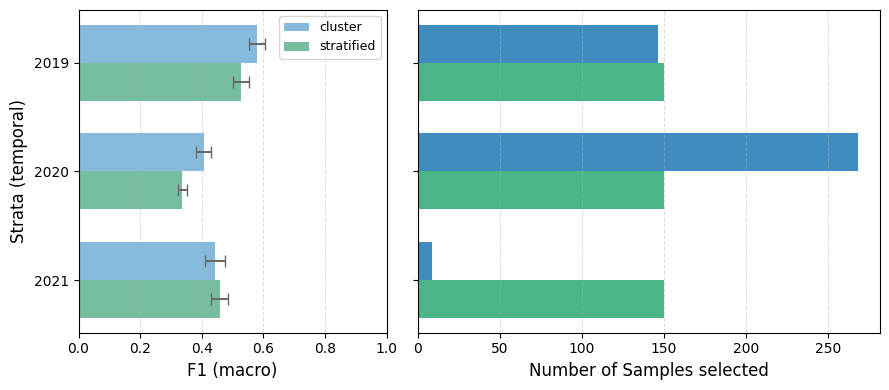

In [79]:
# ============================================================
# Plot
# ============================================================

COLOR_A_SCORE = "#71afd8"
COLOR_A = '#1f78b4'   # blue
COLOR_B_SCORE = "#5eb38e"
COLOR_B = '#2aaa72'   # green
BAR_HEIGHT = 0.35

n = len(strata)
y = np.arange(n)           # positions (bottom -> top when plotted reversed)
strata_rev = strata[::-1]  # top-to-bottom label order

fig, axes = plt.subplots(1, 2,
                          figsize=(9, max(4, n * 0.9)),
                          gridspec_kw={'width_ratios': [2, 3]},
                          sharey=True)

ax_score, ax_counts = axes

label_a = ra.get('label', 'Method A')
label_b = rb.get('label', 'Method B') if rb else None

if rb_mean is None:
    # Single method — centred bars
    ax_score.barh(y, ra_mean[::-1], height=BAR_HEIGHT * 2,
                  xerr=ra_var[::-1], color=COLOR_A, alpha=0.85,
                  capsize=4, ecolor='dimgrey', label=label_a)
    ax_counts.barh(y, ra_counts[::-1], height=BAR_HEIGHT * 2,
                   color=COLOR_A, alpha=0.85, label=label_a)
else:
    # Two methods — offset bars
    offset = BAR_HEIGHT / 2
    ax_score.barh(y + offset, ra_mean[::-1], height=BAR_HEIGHT,
                  xerr=ra_var[::-1], color=COLOR_A_SCORE, alpha=0.85,
                  capsize=4, ecolor='dimgrey', label=label_a)
    ax_score.barh(y - offset, rb_mean[::-1], height=BAR_HEIGHT,
                  xerr=rb_var[::-1], color=COLOR_B_SCORE, alpha=0.85,
                  capsize=4, ecolor='dimgrey', label=label_b)

    ax_counts.barh(y + offset, ra_counts[::-1], height=BAR_HEIGHT,
                   color=COLOR_A, alpha=0.85, label=label_a)
    ax_counts.barh(y - offset, rb_counts[::-1], height=BAR_HEIGHT,
                   color=COLOR_B, alpha=0.85, label=label_b)

# # Mean reference lines
# ax_score.axvline(np.mean(ra_mean), color=COLOR_A, alpha=0.6, linestyle='--', linewidth=1.5)
# if rb_mean is not None:
#     ax_score.axvline(np.mean(rb_mean), color=COLOR_B, alpha=0.6, linestyle='--', linewidth=1.5)

strata_mode = ra.get('strata_mode', 'strata')
ax_score.set_xlabel(metric, fontsize=12)
ax_score.set_ylabel(f'Strata ({strata_mode})', fontsize=12)
ax_score.set_xlim(0, 1.0)
ax_score.set_yticks(y)
ax_score.set_yticklabels(strata_rev, fontsize=10)
ax_score.tick_params(axis='x', labelsize=10)
ax_score.grid(True, axis='x', linestyle='--', alpha=0.4)
ax_score.legend(fontsize=9, loc='upper right')

ax_counts.set_xlabel('Number of Samples selected', fontsize=12)
ax_counts.tick_params(axis='x', labelsize=10)
ax_counts.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

out_fig = f"figures/comparison_{label_a}_vs_{label_b}.pdf" if rb else f"figures/{label_a}.pdf"
plt.savefig(out_fig, bbox_inches='tight')
print(f'Saved figure to {out_fig}')
plt.show()